# BEKO PCL Presence Inference Notebook
This notebook performs presence detection on PCL connectors using trained ResNet18 models.


In [11]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import json
import torch
import torch.nn as nn
from torchvision import models, transforms
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [12]:
class OcclusionCNN(nn.Module):
    def __init__(self):
        super(OcclusionCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 2)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class PCLPresenceClassifier(nn.Module):
    def __init__(self, input_channels=1, pretrained=False):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        if input_channels == 1:
            self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 1)

    def forward(self, x):
        return self.backbone(x)

In [13]:
@dataclass
class RelativeROI:
    name: str
    x_min_rel: float
    y_min_rel: float
    x_max_rel: float
    y_max_rel: float
    
    def to_pixel_box(self, width: int, height: int, margin: int = 0):
        x_min = int(self.x_min_rel * width)
        y_min = int(self.y_min_rel * height)
        x_max = int(self.x_max_rel * width)
        y_max = int(self.y_max_rel * height)
        x_min = max(0, x_min - margin)
        y_min = max(0, y_min - margin)
        x_max = min(width, x_max + margin)
        y_max = min(height, y_max + margin)
        return x_min, y_min, x_max, y_max

def load_roi_config(roi_config_path):
    with open(roi_config_path, 'r') as f:
        data = json.load(f)
    return [RelativeROI(**entry) for entry in data]

def normalize_roi(img: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray).astype(np.float32) / 255.0

def extract_connectors(aligned_image, rois, margin=10):
    height, width = aligned_image.shape[:2]
    extracted = []
    for roi in rois:
        xmin, ymin, xmax, ymax = roi.to_pixel_box(width, height, margin=margin)
        crop_bgr = aligned_image[ymin:ymax, xmin:xmax]
        extracted.append({
            'name': roi.name,
            'crop': normalize_roi(crop_bgr),
            'crop_bgr': crop_bgr,
            'bbox': (xmin, ymin, xmax, ymax)
        })
    return extracted

In [14]:
WEIGHTS_DIR = Path("weights")
MODELS_DIR  = Path("models")
ROI_CONFIG_PATH = Path("config/roi_config.json")

ROIS = load_roi_config(ROI_CONFIG_PATH)
occ_model = OcclusionCNN().to(DEVICE)
occ_weights_path = MODELS_DIR / "occlusion_cnn.pth"
if occ_weights_path.exists():
    occ_model.load_state_dict(torch.load(occ_weights_path, map_location=DEVICE, weights_only=True))
    occ_model.eval()
    print("✅ Occlusion model loaded.")

pcl_models = {}
for cid in [f"conn{i}" for i in range(1, 10)]:
    d = WEIGHTS_DIR / cid
    model_path = list(d.glob("model*.pt"))
    thresh_path = list(d.glob("threshold*.json"))
    if model_path and thresh_path:
        m = PCLPresenceClassifier().to(DEVICE)
        m.load_state_dict(torch.load(model_path[0], map_location=DEVICE, weights_only=True))
        m.eval()
        with open(thresh_path[0]) as f: threshold = json.load(f)['threshold']
        pcl_models[cid] = (m, threshold)
        print(f"✅ {cid} loaded.")

✅ Occlusion model loaded.
✅ conn1 loaded.
✅ conn2 loaded.
✅ conn3 loaded.
✅ conn4 loaded.
✅ conn5 loaded.
✅ conn6 loaded.
✅ conn7 loaded.
✅ conn8 loaded.
✅ conn9 loaded.


conn1: Logits=[ 3.5456417 -0.5338421], Probs=[0.98336524 0.0166348 ]
conn2: Logits=[-3.6752343  4.633716 ], Probs=[2.4624178e-04 9.9975377e-01]
conn3: Logits=[-0.51929706  2.6940455 ], Probs=[0.03866669 0.96133333]
conn4: Logits=[12.102687 -5.294376], Probs=[1.0000000e+00 2.7832476e-08]
conn5: Logits=[ 0.95640874 -0.41599694], Probs=[0.79776853 0.20223147]
conn6: Logits=[ 5.2218094 -1.1450245], Probs=[0.99828535 0.00171464]
conn7: Logits=[ 7.1151056 -2.0301876], Probs=[9.9989331e-01 1.0670955e-04]
conn8: Logits=[ 7.0569253 -1.8133528], Probs=[9.9985945e-01 1.4048374e-04]
conn9: Logits=[ 0.7232104  -0.72980547], Probs=[0.8104621  0.18953787]


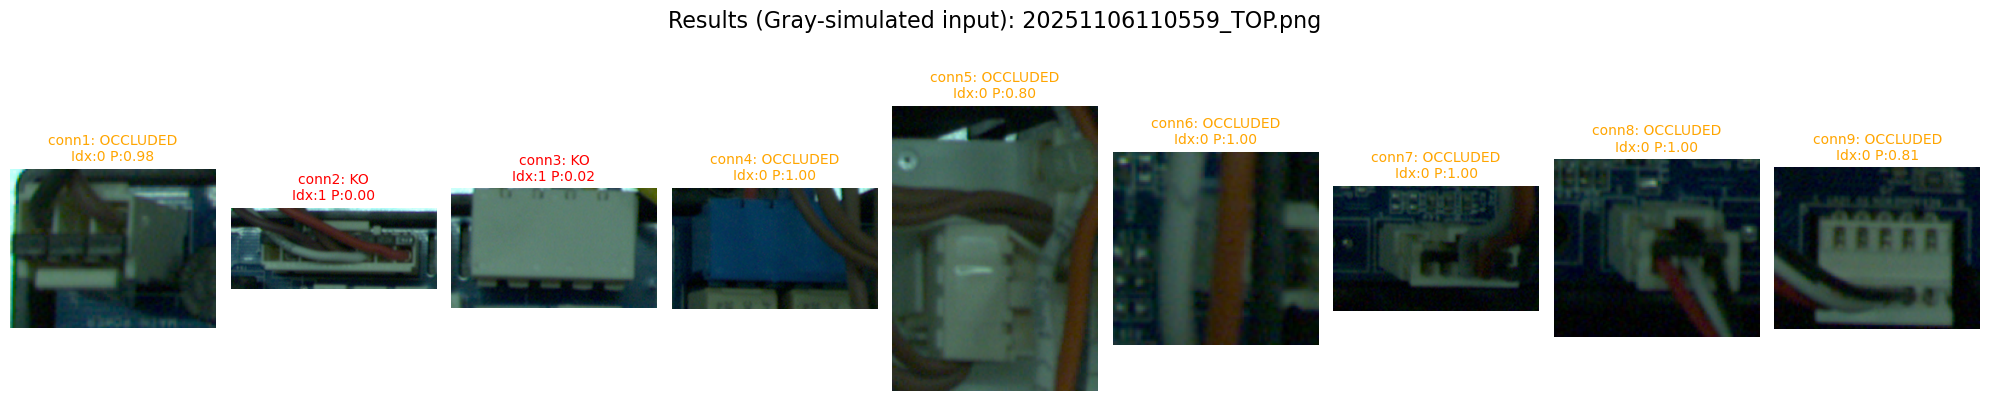

In [15]:
occ_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

SAMPLE_IMG_PATH = Path("../Data/aligned_top/20251106110559_TOP.png")

if SAMPLE_IMG_PATH.exists():
    full_img = cv2.imread(str(SAMPLE_IMG_PATH))
    extracted_connectors = extract_connectors(full_img, ROIS)
    
    fig, axes = plt.subplots(1, 9, figsize=(20, 4))
    
    for i, conn in enumerate(extracted_connectors):
        cid = conn['name']
        # The system saves the normalized grayscale crop and re-opens it for occlusion
        # We simulate this by converting the [0,1] normalization back to uint8 grayscale
        crop_gray_uint8 = (conn['crop'] * 255).astype(np.uint8)
        # Preprocess logic in beko_pcl_presence_system.py repeats channels for grayscale input
        crop_rgb_sim = cv2.cvtColor(crop_gray_uint8, cv2.COLOR_GRAY2RGB)
        pil_img = Image.fromarray(crop_rgb_sim)
        occ_input = occ_transform(pil_img).unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            occ_logits = occ_model(occ_input)
            # Labels in beko_pcl_presence_system.py: 0 is OCCLUSION, 1 is VISIBLE
            probs = torch.softmax(occ_logits, dim=1).cpu().numpy()[0]
            pred_idx = np.argmax(probs)
            
            is_occluded = (pred_idx == 0)
            
        if is_occluded:
            pred = "OCCLUDED"
            color = 'orange'
            score = probs[0]
        else:
            if cid in pcl_models:
                model, threshold = pcl_models[cid]
                t_input = torch.from_numpy(conn['crop']).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    prob_ko = torch.sigmoid(model(t_input)).item()
                    pred = "KO" if prob_ko > threshold else "OK"
                color = 'red' if pred == "KO" else 'green'
                score = prob_ko
            else:
                pred = "N/A"; color = 'gray'; score = 0.0
        
        axes[i].imshow(conn['crop_bgr'][:,:,::-1])
        axes[i].set_title(f"{cid}: {pred}\nIdx:{pred_idx} P:{score:.2f}", color=color, fontsize=10)
        axes[i].axis('off')
        print(f"{cid}: Logits={occ_logits.cpu().numpy()[0]}, Probs={probs}")
    
    plt.suptitle(f"Results (Gray-simulated input): {SAMPLE_IMG_PATH.name}", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()